# 04 - Rendimiento MGCECDL

Carga el mejor clasificador desde `data/models` (el mas reciente si hay varios con timestamp), evalua clasificacion y genera radares SHAP de modalidad. Las figuras se muestran en el cuaderno; `reports/mgcecdl-results/` queda disponible para resultados futuros.


In [1]:
import importlib
import json
import os
import shutil
import subprocess
import sys
from pathlib import Path

import numpy as np
import torch

REPO_URL = "https://github.com/jclugor/chec-local-uiti-vano-interpreter.git"
REPO_NAME = "chec-local-uiti-vano-interpreter"


def resolve_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src" / "chec_impacto").exists():
            return candidate
    working_root = Path("/kaggle/working") if Path("/kaggle/working").exists() else cwd
    clone_dir = working_root / REPO_NAME
    if not clone_dir.exists():
        subprocess.run(["git", "clone", REPO_URL, str(clone_dir)], check=True)
    return clone_dir.resolve()


def install_project_requirements(project_root):
    requirements_path = project_root / "requirements.txt"
    if not requirements_path.exists():
        raise FileNotFoundError(f"No existe requirements.txt en {project_root}")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_path)],
        check=True,
    )


def ensure_lfs_data(project_root):
    data_path = project_root / "data" / "Indicadores_vano_v3.csv"
    if shutil.which("git-lfs") and (project_root / ".git").exists():
        subprocess.run(["git", "lfs", "install", "--local"], cwd=project_root, check=False)
        subprocess.run(["git", "lfs", "pull"], cwd=project_root, check=True)
    if data_path.exists() and data_path.stat().st_size < 1024:
        head = data_path.read_text(errors="ignore")[:120]
        if "git-lfs" in head:
            raise RuntimeError(
                "Indicadores_vano_v3.csv quedo como puntero Git LFS. "
                "Descarga el archivo LFS antes de continuar."
            )


PROJECT_ROOT = resolve_project_root()
install_project_requirements(PROJECT_ROOT)
ensure_lfs_data(PROJECT_ROOT)

importlib.invalidate_caches()
for _mod in list(sys.modules):
    if _mod == "chec_impacto" or _mod.startswith("chec_impacto."):
        del sys.modules[_mod]

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

os.chdir(PROJECT_ROOT)
DATA_DIR      = PROJECT_ROOT / "data"
MODEL_DIR     = DATA_DIR / "models"
RESULTS_DIR   = PROJECT_ROOT / "reports" / "mgcecdl-results"
SITE_RESULTS_DIR = PROJECT_ROOT / "src" / "assets" / "site" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SITE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
NOMBRE_MODELO = "MGCECDL"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("CUDA disponible:", torch.cuda.is_available())
print("MPS disponible:", torch.backends.mps.is_available())

Updated Git hooks.
Git LFS initialized.
PROJECT_ROOT: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter
DATA_DIR: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/data
RESULTS_DIR: /Users/diego/Desktop/Reporte/chec-local-uiti-vano-interpreter/reports/mgcecdl-results
CUDA disponible: False
MPS disponible: True


In [2]:
from chec_impacto.data import (
    construir_matriz_adyacencia_mgcecdl,
    preparar_splits_estratificados,
    procesar_dataset_completo,
)
from chec_impacto.training import (
    construir_modalidades_mgcecdl,
    escalar_features_minmax_mgcecdl,
    resolve_training_device,
)

VENTANA_CLIMATICA_HORAS = 12
FILTRO_UITI_MAX         = None
RANDOM_STATE            = 42

DATA_PATH_CANDIDATES = [
    DATA_DIR / "Indicadores_vano_v3.csv",
    DATA_DIR / "Indicadores_vano_v2.csv",
    DATA_DIR / "Indicadores_vano_v1.csv",
]
DATASET_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError("No se encontro Indicadores_vano_v3/v2/v1.csv en data/.")

VARIABLES_SELECCION_PATH = DATA_DIR / "Variables_seleccion.xlsx"
DEVICE = resolve_training_device("auto")
print(f"Usando device: {DEVICE}")

datos_procesados = procesar_dataset_completo(
    path_clima=DATASET_PATH,
    path_variables_seleccion=VARIABLES_SELECCION_PATH,
    use_sampling=False,
    min_samples_per_codigo=5,
    target="UITI_VANO",
    filtro_uiti_max=FILTRO_UITI_MAX,
    ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
)
X        = datos_procesados["X"]
y        = datos_procesados["y"]
features = datos_procesados["features"]

modality_feature_indices = construir_modalidades_mgcecdl(features)
graph_adjacency_matrix, _ = construir_matriz_adyacencia_mgcecdl(
    features, ventana_climatica_horas=VENTANA_CLIMATICA_HORAS
)

splits_por_modo = {
    "clasificacion": escalar_features_minmax_mgcecdl(
        preparar_splits_estratificados(
            X,
            y,
            modo="clasificacion",
            random_state=RANDOM_STATE,
        )
    )
}
print("Split de clasificacion generado:", splits_por_modo["clasificacion"]["X_train"].shape)


Usando device: mps
Cargando datos...
Procesamiento completado.
Shape X: (159470, 70), Shape y: (159470, 1)
Dataset original: X=(159470, 70), y=(159470, 1)
Splits generados -> Train: (102060, 70), Valid: (25516, 70), Test: (31894, 70)
Modo objetivo: clasificacion

Distribución de clases para estratificación:
Original: [39868 39867 39867 39868]
Train:    [25515 25515 25515 25515]
Valid:    [6379 6379 6379 6379]
Test:     [7974 7973 7973 7974]
Split de clasificacion generado: (102060, 70)


In [3]:
from chec_impacto.training import cargar_modelo_mgcecdl


def _modelo_mas_reciente(model_dir: Path, base_name: str) -> Path:
    """Devuelve el modelo mas reciente si existe."""
    stem = Path(base_name).stem
    suffix = Path(base_name).suffix
    candidates = sorted(model_dir.glob(f"{stem}*{suffix}"))
    if not candidates:
        raise FileNotFoundError(f"No se encontro {base_name} en {model_dir}.")
    selected = candidates[-1]
    if len(candidates) > 1:
        print(f"  [{base_name}] {len(candidates)} versiones. Usando: {selected.name}")
    return selected


model_path = _modelo_mas_reciente(MODEL_DIR, "mgcecdl_classifier_best.zip")
modelo = cargar_modelo_mgcecdl(str(model_path), device=DEVICE)
modelos = {"clasificacion": modelo}

print("Modelo cargado:", type(modelo).__name__)
print(f"  clasificacion: {model_path.name}")


Modelo cargado: MGCECDLClassifier
  clasificacion: mgcecdl_classifier_best.zip


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seleccion = pd.read_excel(VARIABLES_SELECCION_PATH)
variables_seleccionadas = set(
    seleccion.loc[
        pd.to_numeric(seleccion["SELECCIÓN"], errors="coerce").fillna(0).eq(1),
        "COLUMNA",
    ].astype(str).str.strip()
)

PREFIJOS_CLIMATICOS = {"prep", "clouds", "wind_spd", "wind_gust_spd", "temp"}


def expandir_variables(*variables):
    columnas = []
    for variable in variables:
        if variable not in variables_seleccionadas or variable == "UITI_VANO":
            continue
        if variable in PREFIJOS_CLIMATICOS:
            columnas.extend(feature for feature in features if feature.startswith(f"{variable}_"))
        elif variable in features:
            columnas.append(variable)
    return list(dict.fromkeys(columnas))


MODOS_RADAR = {
    "Evento, impacto\ne indicadores": expandir_variables(
        "FECHA", "DURACION", "TOT_USUS", "CNT_TRF", "COD_CAUSA", "UITI", "UITI_VANO"
    ),
    "Infraestructura de\nprotección y maniobra": expandir_variables(
        "FID_SW", "COD_EQ_PROTEGE", "TIPO", "CNT_VN", "CNT_VN_SW", "T_USUS_EQ_PROT"
    ),
    "Topología y\nconfiguración espacial": expandir_variables(
        "CIRCUITO", "FID_VANO", "X1", "Y1", "X2", "Y2", "LVSW", "PORC_APORTE_VANO"
    ),
    "Características físicas\ny eléctricas del vano": expandir_variables(
        "FECHA_OPERACION_VANO", "LONGITUD", "CNT_FASES", "CONDUCTOR",
        "CALIBRE_NEUTRO", "NG_RED", "PROMEDIO_KWH_VANO", "TIPO_TAX"
    ),
    "Activos: apoyo final\ny transformador": expandir_variables(
        "COD_APOYO_FIN", "FID_APOYO_FIN", "ALTURA", "CANTIDAD_TIERRA",
        "PROPIETARIO", "CLASE", "ELEMENTO", "NORMA", "VAL_CRIT_APOYO",
        "LONG_CRUCETA", "FID_TRAFO", "CODIGO", "CAPACIDAD_NOMINAL",
        "CNT_USUS", "FECHA_OPERACION_TRF", "PROMEDIO_KWH_TRF"
    ),
    "Entorno, riesgo\ny clima": expandir_variables(
        "NR_T", "DDT", "prep", "clouds", "wind_spd", "wind_gust_spd", "temp"
    ),
}
MODOS_RADAR = {nombre: columnas for nombre, columnas in MODOS_RADAR.items() if columnas}
variables_mapeadas = [variable for columnas in MODOS_RADAR.values() for variable in columnas]
if len(variables_mapeadas) != len(set(variables_mapeadas)):
    raise ValueError("Hay variables repetidas entre los modos del radar.")
variables_sin_modo = sorted(set(features) - set(variables_mapeadas))
if variables_sin_modo:
    raise ValueError(f"Variables seleccionadas sin modo asignado: {variables_sin_modo}")

conteos_modos = pd.Series({nombre.replace("\n", " "): len(columnas) for nombre, columnas in MODOS_RADAR.items()}, name="n_variables")
print("Variables efectivas por modo:")
print(conteos_modos)


Variables efectivas por modo:
Evento, impacto e indicadores                     1
Infraestructura de protección y maniobra          2
Topología y configuración espacial                2
Características físicas y eléctricas del vano     8
Activos: apoyo final y transformador              7
Entorno, riesgo y clima                          50
Name: n_variables, dtype: int64


Métricas de clasificación MGCECDL:
          Métrica    Valor
         Accuracy 0.799304
Balanced Accuracy 0.799300
  Precision Macro 0.798319
     Recall Macro 0.799300
         F1 Macro 0.798663
            Kappa 0.732405
              MCC 0.732497
    AUC Macro OvR 0.946189


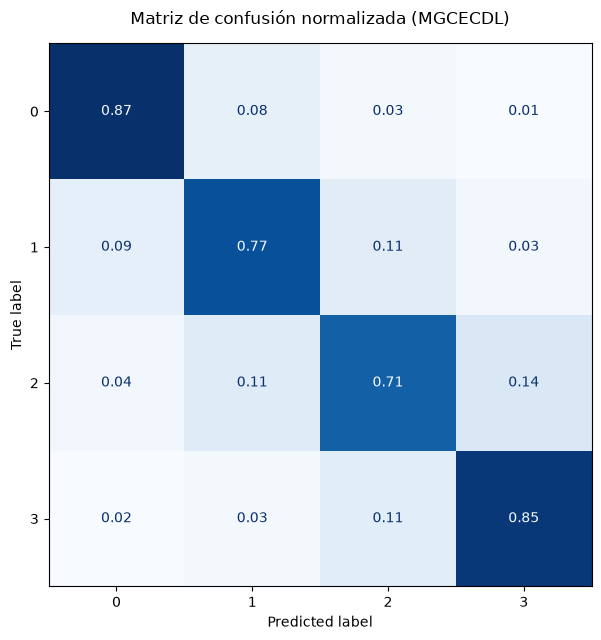

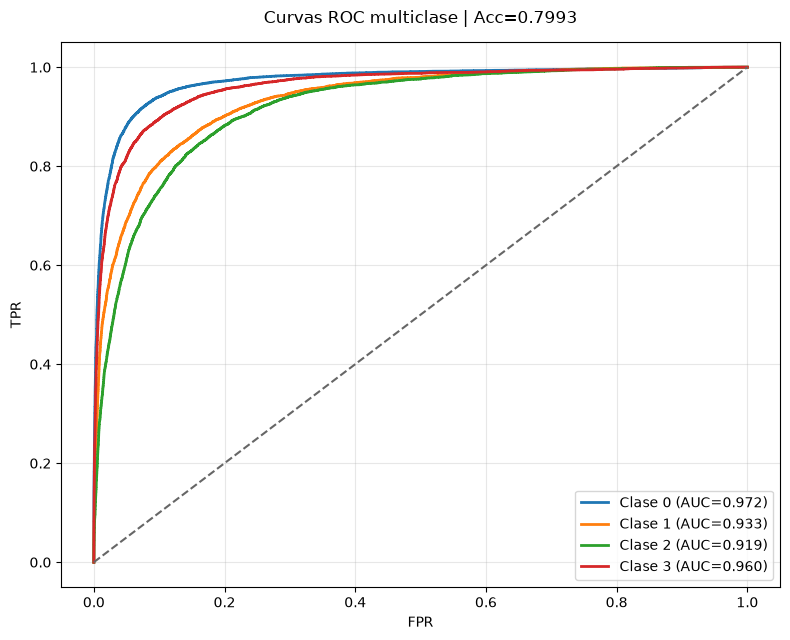

Figuras web actualizadas:
- mgcecdl_confusion_matrix.png
- mgcecdl_roc_curve.png


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score,
    cohen_kappa_score, confusion_matrix, f1_score, matthews_corrcoef,
    precision_score, recall_score, roc_auc_score, roc_curve,
)

from chec_impacto.training import predict_classification
splits_clf = splits_por_modo["clasificacion"]
X_test_clf = splits_clf["X_test"]
y_test_clf = np.asarray(splits_clf["y_test"]).reshape(-1).astype(int)

outputs_clf = predict_classification(modelos["clasificacion"], X_test_clf, device=DEVICE)
y_pred      = outputs_clf["predicted_classes"]
y_prob      = outputs_clf["fused_probs"]
modality_names = list(outputs_clf["modality_names"])

# ── Métricas globales ────────────────────────────────────────────────────────
estadisticos = {
    "Accuracy":           accuracy_score(y_test_clf, y_pred),
    "Balanced Accuracy":  balanced_accuracy_score(y_test_clf, y_pred),
    "Precision Macro":    precision_score(y_test_clf, y_pred, average="macro", zero_division=0),
    "Recall Macro":       recall_score(y_test_clf, y_pred, average="macro", zero_division=0),
    "F1 Macro":           f1_score(y_test_clf, y_pred, average="macro", zero_division=0),
    "Kappa":              cohen_kappa_score(y_test_clf, y_pred),
    "MCC":                matthews_corrcoef(y_test_clf, y_pred),
    "AUC Macro OvR":      roc_auc_score(y_test_clf, y_prob, multi_class="ovr", average="macro"),
}
import pandas as pd
df_metricas = pd.DataFrame(list(estadisticos.items()), columns=["Métrica", "Valor"])
print("Métricas de clasificación MGCECDL:")
print(df_metricas.to_string(index=False))


# ── Matriz de confusión + ROC ────────────────────────────────────────────────
clases = np.arange(y_prob.shape[1])
cm_norm = confusion_matrix(y_test_clf, y_pred, labels=clases, normalize="true")

fig_cm, ax_cm = plt.subplots(1, 1, figsize=(7.5, 6.5))
ConfusionMatrixDisplay(cm_norm, display_labels=clases).plot(
    ax=ax_cm, values_format=".2f", colorbar=False, cmap="Blues"
)
ax_cm.set_title("Matriz de confusión normalizada (MGCECDL)", pad=14)
fig_cm.tight_layout()
fig_cm.savefig(RESULTS_DIR / "mgcecdl_confusion_matrix.png", dpi=180, bbox_inches="tight")
fig_cm.savefig(SITE_RESULTS_DIR / "mgcecdl_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

fig_roc, ax_roc = plt.subplots(1, 1, figsize=(8, 6.5))
for clase in range(y_prob.shape[1]):
    y_bin = (y_test_clf == clase).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_prob[:, clase])
    auc_c = roc_auc_score(y_bin, y_prob[:, clase])
    ax_roc.plot(fpr, tpr, linewidth=2, label=f"Clase {clase} (AUC={auc_c:.3f})")
ax_roc.plot([0, 1], [0, 1], "--", color="#666666")
ax_roc.set_title(f"Curvas ROC multiclase | Acc={estadisticos['Accuracy']:.4f}", pad=14)
ax_roc.set_xlabel("FPR")
ax_roc.set_ylabel("TPR")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.3)
fig_roc.tight_layout()
fig_roc.savefig(RESULTS_DIR / "mgcecdl_roc_curve.png", dpi=180, bbox_inches="tight")
fig_roc.savefig(SITE_RESULTS_DIR / "mgcecdl_roc_curve.png", dpi=180, bbox_inches="tight")
plt.show()

print("Figuras web actualizadas:")
print("- mgcecdl_confusion_matrix.png")
print("- mgcecdl_roc_curve.png")


## Radar SHAP de clasificación


Calculando SHAP MGCECDL - clasificacion...


  0%|          | 0/1000 [00:00<?, ?it/s]

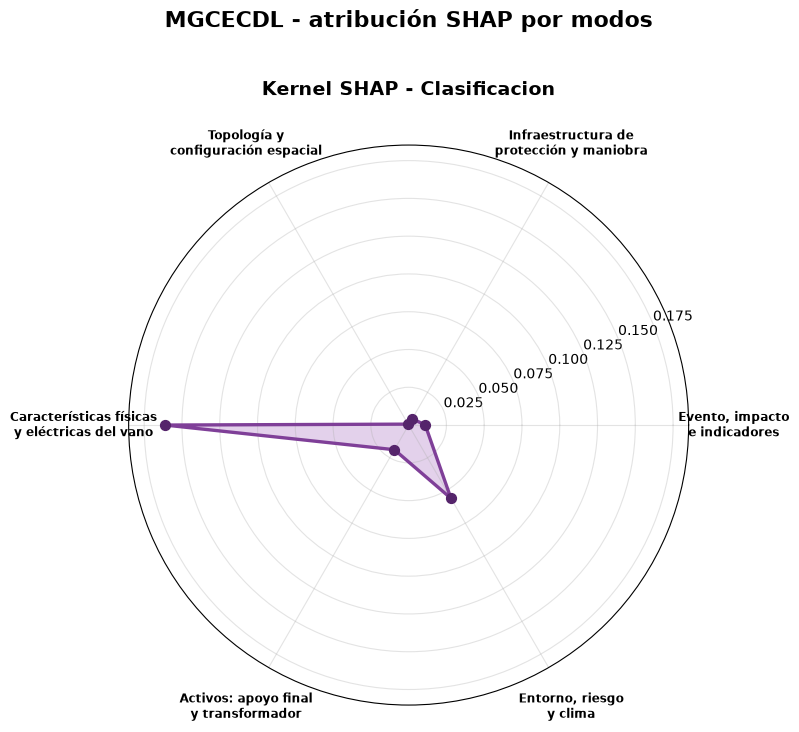

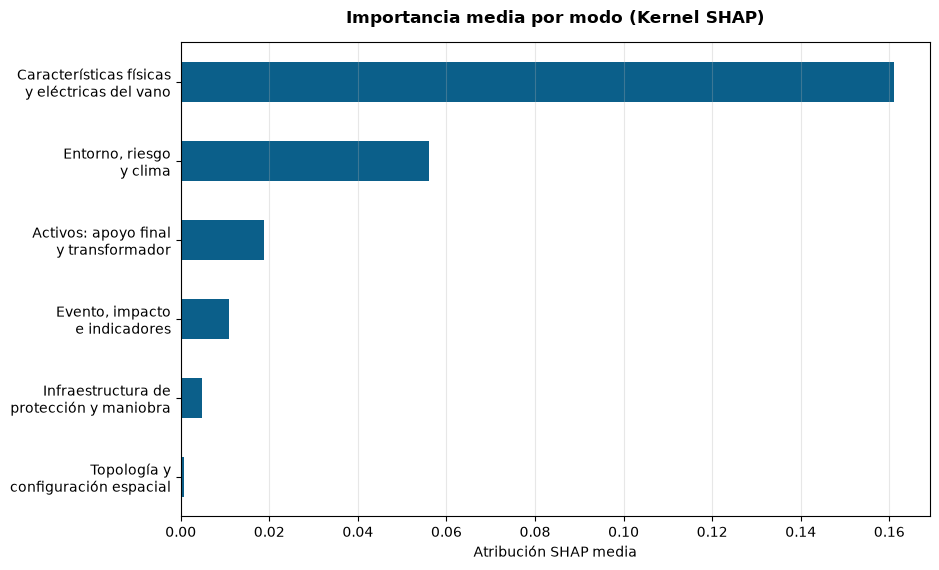

Figura web actualizada: mgcecdl_mode_importance.png


In [6]:
import shap
from chec_impacto.training import predict_classification


def matriz_shap_absoluta(shap_values, n_features):
    if isinstance(shap_values, list):
        matrices = [np.asarray(values) for values in shap_values]
        return np.mean(np.abs(np.stack(matrices, axis=0)), axis=0)

    values = np.asarray(shap_values)
    if values.ndim == 2:
        return np.abs(values)
    if values.ndim == 3 and values.shape[1] == n_features:
        return np.mean(np.abs(values), axis=2)
    if values.ndim == 3 and values.shape[2] == n_features:
        return np.mean(np.abs(values), axis=0)
    raise ValueError(f"Formato SHAP no soportado: {values.shape}")


def _predict_fn_shap(modelo, X_background):
    def predict_shap(values):
        values = np.asarray(values, dtype=np.float32)
        if values.ndim == 1:
            values = values.reshape(1, -1)
        lote_unitario = len(values) == 1
        if lote_unitario:
            values = np.vstack([values, X_background[0:1]])

        predictions = np.asarray(
            predict_classification(modelo, values, device=DEVICE)["fused_probs"]
        )
        return predictions[:1] if lote_unitario else predictions

    return predict_shap


def generar_radares_shap_modelos(
    modelos, X_referencia, output_path, background_size=50, sample_size=1000,
    nsamples=300, seed=42, titulo_figura=None,
):
    if "clasificacion" not in modelos:
        print(f"No hay clasificador {NOMBRE_MODELO} disponible para calcular radar SHAP.")
        return {}

    rng = np.random.default_rng(seed)
    X_referencia = np.asarray(X_referencia, dtype=np.float32)
    if X_referencia.shape[1] != len(features):
        raise ValueError("El número de columnas no coincide con las características del modelo.")

    bg_idx = rng.choice(len(X_referencia), size=min(background_size, len(X_referencia)), replace=False)
    eval_idx = rng.choice(len(X_referencia), size=min(sample_size, len(X_referencia)), replace=False)
    X_background = X_referencia[bg_idx]
    X_eval = X_referencia[eval_idx]
    puntajes_modelos = {}

    print(f"Calculando SHAP {NOMBRE_MODELO} - clasificacion...")
    predict_shap = _predict_fn_shap(modelos["clasificacion"], X_background)
    explainer = shap.KernelExplainer(predict_shap, X_background)
    shap_values = explainer.shap_values(X_eval, nsamples=nsamples)
    shap_abs = matriz_shap_absoluta(shap_values, len(features))
    df_shap = pd.DataFrame(shap_abs, columns=features)
    puntajes_modelos["clasificacion"] = pd.Series({
        nombre: float(df_shap[columnas].sum(axis=1).mean())
        for nombre, columnas in MODOS_RADAR.items()
    }, name="atribucion_shap_media")

    maximo = puntajes_modelos["clasificacion"].max() * 1.15
    fig, ax = plt.subplots(1, 1, figsize=(9, 8), subplot_kw={"polar": True})
    puntajes = puntajes_modelos["clasificacion"]
    angulos = np.linspace(0, 2 * np.pi, len(puntajes), endpoint=False)
    ax.plot(np.r_[angulos, angulos[0]], np.r_[puntajes.values, puntajes.values[0]], color="#7f3f98", linewidth=2.4)
    ax.fill(np.r_[angulos, angulos[0]], np.r_[puntajes.values, puntajes.values[0]], color="#b07cc6", alpha=0.35)
    ax.scatter(angulos, puntajes.values, color="#55246b", s=50, zorder=3)
    ax.set_xticks(angulos)
    ax.set_xticklabels(puntajes.index, fontsize=8.5, fontweight="bold")
    ax.tick_params(axis="x", pad=22)
    ax.set_ylim(0, maximo if maximo > 0 else 1.0)
    ax.grid(alpha=0.35)
    ax.set_title("Kernel SHAP - Clasificacion", fontsize=14, fontweight="bold", pad=36)
    if titulo_figura is None:
        titulo_figura = f"{NOMBRE_MODELO} - atribución SHAP por modos"
    fig.suptitle(titulo_figura, fontsize=16, fontweight="bold", y=0.99)
    fig.subplots_adjust(top=0.82, bottom=0.12, left=0.06, right=0.94, wspace=0.32)
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    fig.savefig(SITE_RESULTS_DIR / "mgcecdl_mode_importance_radar.png", dpi=180, bbox_inches="tight")
    plt.show()

    fig_bar, ax_bar = plt.subplots(1, 1, figsize=(9.5, 5.8))
    puntajes.sort_values().plot(kind="barh", ax=ax_bar, color="#0b5f8a")
    ax_bar.set_title("Importancia media por modo (Kernel SHAP)", pad=14, fontweight="bold")
    ax_bar.set_xlabel("Atribución SHAP media")
    ax_bar.grid(axis="x", alpha=0.3)
    fig_bar.tight_layout()
    fig_bar.savefig(RESULTS_DIR / "mgcecdl_mode_importance.png", dpi=180, bbox_inches="tight")
    fig_bar.savefig(SITE_RESULTS_DIR / "mgcecdl_mode_importance.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("Figura web actualizada: mgcecdl_mode_importance.png")
    return puntajes_modelos


radares_shap = generar_radares_shap_modelos(
    modelos, X, RESULTS_DIR / "radar_shap_clasificacion.png"
)
